# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [2]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    # TODO: Implement a tokenization strategy
    B, C, H, W = x.shape
    gh, gw = H // patch_size, W // patch_size
    x = x.reshape(B, C, gh, patch_size, gw, patch_size)
    x = x.permute(0, 2, 4, 3, 5, 1)  # (B, gh, gw, P, P, C)
    x = x.reshape(B, gh * gw, patch_size * patch_size * C)
    return x

In [4]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        # TODO: implement
        self.proj = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.proj(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        # TODO: implement
        self.pos_embed = nn.Parameter(torch.randn(1, num_tokens, d_model) * 0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return x + self.pos_embed

In [5]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
#
# We compare:
#   1. Baseline FFN (GELU) — standard Transformer MLP
#   2. GEGLU — gates with GELU; shown by Shazeer to improve over baseline on many tasks
#   3. SwiGLU — gates with SiLU/Swish; used in LLaMA and PaLM, often best GLU variant
#
# Justification: GEGLU and SwiGLU are the two most widely adopted GLU variants in
# modern Transformer architectures. They use smooth gating activations (GELU and SiLU
# respectively) which tend to outperform sharp gates (e.g. sigmoid in vanilla GLU).

class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        # TODO: implement
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class GLUFeedForward(nn.Module):
    """GLU-family FFN
    
    Uses the 2/3 width rule from Shazeer to keep parameter count comparable:
    standard FFN has 2 * d_model * d_ff parameters in linear layers,
    GLU has 3 * d_model * d_ff_gated, so d_ff_gated = 2/3 * d_ff.
    """
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        # TODO: implement
        self.variant = variant
        # Gate projection and value projection
        self.w_gate = nn.Linear(d_model, d_ff_gated)
        self.w_val = nn.Linear(d_model, d_ff_gated)
        self.w_out = nn.Linear(d_ff_gated, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        gate = self.w_gate(x)
        val = self.w_val(x)
        if self.variant == "geglu":
            gate = F.gelu(gate)
        elif self.variant == "swiglu":
            gate = F.silu(gate)
        else:
            raise ValueError(f"Unknown GLU variant: {self.variant}")
        x = gate * val
        x = self.dropout(x)
        x = self.w_out(x)
        x = self.dropout(x)
        return x

In [6]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        # TODO: implement. For attention use nn.MultiHeadAttention 
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = mlp
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        # Self-attention with pre-LN
        x_ln = self.ln1(x)
        attn_out, _ = self.attn(x_ln, x_ln, x_ln)
        x = x + self.drop1(attn_out)
        # MLP with pre-LN
        x = x + self.drop2(self.mlp(self.ln2(x)))
        return x

In [7]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        # TODO: implement a strategy for embedding the patches
        self.patch_embed = PatchEmbed(patch_dim, d_model)
        self.pos_embed = PositionalEmbedding(self.num_tokens, d_model)
        self.embed_drop = nn.Dropout(dropout)

        # TODO: implement a strategy to select the right mlp version for your experiment
        # Apply the 2/3 width rule for GLU variants to keep param count comparable
        d_ff_gated = int(2 * d_ff / 3)

        def make_mlp():
            if mlp_kind == "ffn":
                return FeedForward(d_model, d_ff, dropout)
            else:
                return GLUFeedForward(d_model, d_ff_gated, dropout, variant=mlp_kind)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=make_mlp(), # TODO: Feed your mlp to the encoder blocks
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement
        patches = patchify(x, self.patch_size)       # (B, num_tokens, patch_dim)
        x = self.patch_embed(patches)                 # (B, num_tokens, d_model)
        x = self.pos_embed(x)                         # add positional embeddings
        x = self.embed_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        x = x.mean(dim=1)                            # mean pool over tokens
        logits = self.head(x)                         # (B, 10)
        return logits

In [8]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [9]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb) # TODO: Your criterion

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        # TODO: Return your metrics that you think will support your claim for this experiment
        "mlp_kind": mlp_kind,
        "train_losses": train_losses,
        "test_accs": test_accs,
        "best_test_acc": max(test_accs),
        "final_test_acc": test_accs[-1],
        "num_params": sum(p.numel() for p in model.parameters()),
    }

In [10]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["ffn", "geglu", "swiglu"] # TODO: Name your runs
results = []

for kind in runs:
    torch.manual_seed(cfg.seed)
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    # TODO: print anything you might want here
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nRun: {kind} | params: {n_params:,}")
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append(out)


Run: ffn | params: 104,970
[ffn] epoch 1/5 | test acc: 0.7887
[ffn] epoch 2/5 | test acc: 0.8979
[ffn] epoch 3/5 | test acc: 0.9270
[ffn] epoch 4/5 | test acc: 0.9373
[ffn] epoch 5/5 | test acc: 0.9506

Run: geglu | params: 104,882
[geglu] epoch 1/5 | test acc: 0.8260
[geglu] epoch 2/5 | test acc: 0.9185
[geglu] epoch 3/5 | test acc: 0.9444
[geglu] epoch 4/5 | test acc: 0.9576
[geglu] epoch 5/5 | test acc: 0.9622

Run: swiglu | params: 104,882
[swiglu] epoch 1/5 | test acc: 0.8289
[swiglu] epoch 2/5 | test acc: 0.9192
[swiglu] epoch 3/5 | test acc: 0.9441
[swiglu] epoch 4/5 | test acc: 0.9557
[swiglu] epoch 5/5 | test acc: 0.9603


Variant        Params   Best Acc  Final Acc
--------------------------------------------
ffn           104,970     0.9506     0.9506
geglu         104,882     0.9622     0.9622
swiglu        104,882     0.9603     0.9603


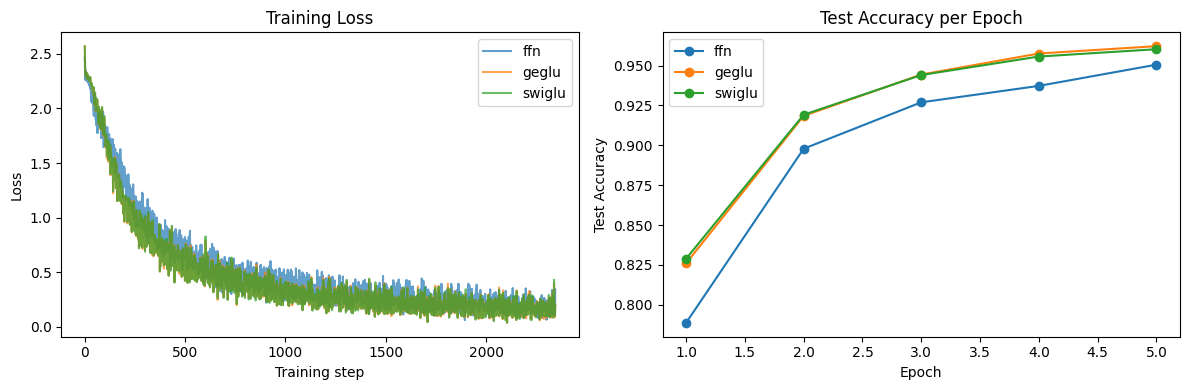

In [14]:
import matplotlib.pyplot as plt

# Summary table
print(f"{'Variant':<10} {'Params':>10} {'Best Acc':>10} {'Final Acc':>10}")
print("-" * 44)
for r in results:
    print(f"{r['mlp_kind']:<10} {r['num_params']:>10,} {r['best_test_acc']:>10.4f} {r['final_test_acc']:>10.4f}")

# Plot training loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in results:
    axes[0].plot(r["train_losses"], label=r["mlp_kind"], alpha=0.7)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

for r in results:
    axes[1].plot(range(1, len(r["test_accs"]) + 1), r["test_accs"], marker="o", label=r["mlp_kind"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Test Accuracy per Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()